In [39]:
!pip install sklearn

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Load dataset
df = pd.read_csv("TPM_Gene_Dataset.tsv", sep="\t")
print(df.head())

   SampleID     ACVR1       ATRX      BRAF  BRCA2    CDKN2A    CDKN2B  \
0  SJ031178  0.600323  12.937409  2.653096    0.0  0.562938  1.188396   
1  SJ031136  0.580560   0.000000  2.441213    0.0  0.000000  0.000000   
2  SJ030326  1.209038  13.882685  2.250472    0.0  1.849287  3.860265   
3  SJ030764  1.007426   6.749429  0.911041    0.0  0.017142  0.118269   
4  SJ030738  0.920879   1.686274  0.111809    0.0  0.030240  0.000000   

      CTNNB1      DDX3X       EGFR  ...    PIK3CA     PIK3R1     PTCH1  \
0  17.239224  14.859794   0.454531  ...  2.974385   9.397190  0.360586   
1  23.490712   0.000000  12.014923  ...  0.043811  19.379355  0.821684   
2  32.134124   4.374138   0.056706  ...  4.464467   8.355226  1.049168   
3  18.565138   0.000000   0.048563  ...  0.004662   0.060905  1.338042   
4  17.015101   0.003061   0.000000  ...  0.049348   0.027629  0.006368   

       PTEN       RB1  SMARCB1  SUFU      TERT      TP53  Label  
0  4.764752  0.022179      0.0   0.0  0.029685  2.

In [4]:
# Drop BT rows
df = df[df["Label"] != "BT"]
print(df.head())

   SampleID     ACVR1       ATRX      BRAF     BRCA2    CDKN2A    CDKN2B  \
0  SJ031178  0.600323  12.937409  2.653096  0.000000  0.562938  1.188396   
2  SJ030326  1.209038  13.882685  2.250472  0.000000  1.849287  3.860265   
4  SJ030738  0.920879   1.686274  0.111809  0.000000  0.030240  0.000000   
5  SJ030620  0.751408  14.844826  1.820069  0.313266  0.081826  0.058984   
7  SJ003236  0.445754   4.354644  1.460783  0.006073  0.366590  0.247277   

      CTNNB1      DDX3X      EGFR  ...    PIK3CA    PIK3R1     PTCH1  \
0  17.239224  14.859794  0.454531  ...  2.974385  9.397190  0.360586   
2  32.134124   4.374138  0.056706  ...  4.464467  8.355226  1.049168   
4  17.015101   0.003061  0.000000  ...  0.049348  0.027629  0.006368   
5  11.646923   6.250821  0.539658  ...  2.696584  4.078594  1.608285   
7   6.650907   1.925802  1.124748  ...  1.081946  4.353235  0.793633   

       PTEN       RB1   SMARCB1      SUFU      TERT      TP53  Label  
0  4.764752  0.022179  0.000000  0.0000

In [5]:
# Split features and label
X = df.drop(columns=["SampleID", "Label"])
y = df["Label"]
print(X.head())
print(y.head())

      ACVR1       ATRX      BRAF     BRCA2    CDKN2A    CDKN2B     CTNNB1  \
0  0.600323  12.937409  2.653096  0.000000  0.562938  1.188396  17.239224   
2  1.209038  13.882685  2.250472  0.000000  1.849287  3.860265  32.134124   
4  0.920879   1.686274  0.111809  0.000000  0.030240  0.000000  17.015101   
5  0.751408  14.844826  1.820069  0.313266  0.081826  0.058984  11.646923   
7  0.445754   4.354644  1.460783  0.006073  0.366590  0.247277   6.650907   

       DDX3X      EGFR      FGFR1  ...    PDGFRA    PIK3CA    PIK3R1  \
0  14.859794  0.454531  49.917784  ...  4.550349  2.974385  9.397190   
2   4.374138  0.056706  12.634317  ...  5.817068  4.464467  8.355226   
4   0.003061  0.000000   9.868204  ...  0.000000  0.049348  0.027629   
5   6.250821  0.539658  23.738742  ...  6.647874  2.696584  4.078594   
7   1.925802  1.124748   4.448394  ...  7.326144  1.081946  4.353235   

      PTCH1      PTEN       RB1   SMARCB1      SUFU      TERT      TP53  
0  0.360586  4.764752  0.02217

In [6]:
# Split train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (267, 26)
X_test shape: (67, 26)
y_train shape: (267,)
y_test shape: (67,)



Classification Report:
              precision    recall  f1-score   support

         HGG       0.74      0.77      0.76        22
         LGG       0.87      0.80      0.83        25
          MB       0.86      0.90      0.88        20

    accuracy                           0.82        67
   macro avg       0.82      0.82      0.82        67
weighted avg       0.82      0.82      0.82        67



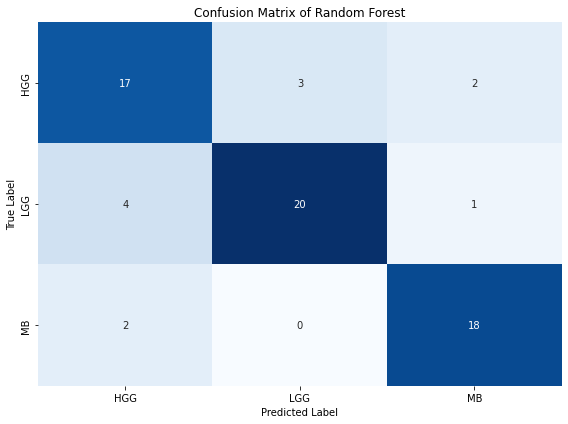

Accuracy on test set: 0.8209


In [7]:
# Train and evaluate RandomForest model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a DataFrame for seaborn with class names
labels = sorted(y.unique())  # sort classes alphabetically
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title("Confusion Matrix of Random Forest")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

accuracy = model.score(X_test, y_test)
print(f"Accuracy on test set: {accuracy:.4f}")

/carter/users/affm17/jupyter-cluster-env/lib64/python3.6/site-packages/sklearn/linear_model/_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)



Classification Report:
              precision    recall  f1-score   support

         HGG       0.67      0.64      0.65        22
         LGG       0.80      0.80      0.80        25
          MB       0.81      0.85      0.83        20

    accuracy                           0.76        67
   macro avg       0.76      0.76      0.76        67
weighted avg       0.76      0.76      0.76        67



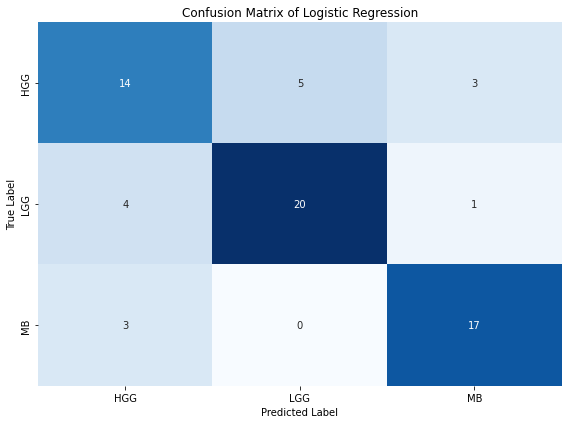

Accuracy on test set: 0.7612


In [8]:
# Train and evaluate LogisticRegression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a DataFrame for seaborn with class names
labels = sorted(y.unique())  # sort classes alphabetically
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title("Confusion Matrix of Logistic Regression")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

accuracy = model.score(X_test, y_test)
print(f"Accuracy on test set: {accuracy:.4f}")


Classification Report:
              precision    recall  f1-score   support

         HGG       0.82      0.41      0.55        22
         LGG       0.66      0.92      0.77        25
          MB       0.86      0.90      0.88        20

    accuracy                           0.75        67
   macro avg       0.78      0.74      0.73        67
weighted avg       0.77      0.75      0.73        67



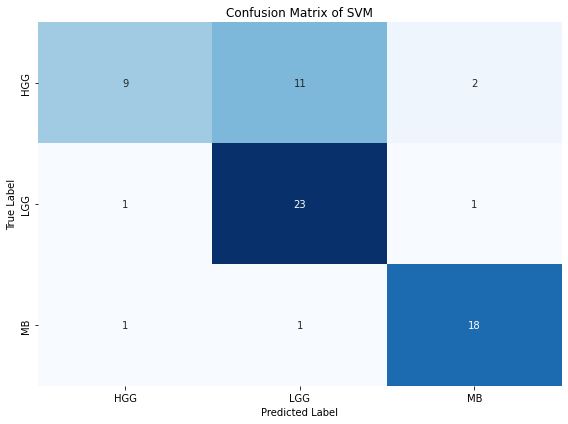

Accuracy on test set: 0.7463


In [9]:
# Train and evaluate SVM model
from sklearn.svm import SVC
model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a DataFrame for seaborn with class names
labels = sorted(y.unique())  # sort classes alphabetically
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title("Confusion Matrix of SVM")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

accuracy = model.score(X_test, y_test)
print(f"Accuracy on test set: {accuracy:.4f}")